## Exercise 3: REM sleep detection

In [2]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats, signal as sp_signal, ndimage
import sys
sys.path.append('../code/')
from lfp_functions import bandpass_filter, power


In [3]:
with open('../data/sleep_lfp.pickle', 'rb') as f:
    data = pickle.load(f)

lfp = np.array(data['lfp'], dtype=float)
fs  = data['sampling_rate']   # fixed: was data['fs']
t   = np.arange(len(lfp)) / fs

print(f'Duration: {t[-1]:.1f} s ({t[-1]/60:.1f} min),  fs = {fs} Hz')


Duration: 1816.6 s (30.3 min),  fs = 1000.0 Hz


In [4]:
# instantaneous power via Morlet CWT (from lfp_functions.py)
# n_freqs=10 keeps it tractable for a long recording
theta_power = power(lfp, low_f=6,  high_f=10, sampling_rate=fs, n_freqs=10)
delta_power = power(lfp, low_f=2,  high_f=4,  sampling_rate=fs, n_freqs=10)

In [5]:
theta_z = stats.zscore(theta_power)
delta_z = stats.zscore(delta_power)

power_diff = theta_z - delta_z

# Smooth with a 5-second boxcar so REM/nREM blocks are stable
# (raw power_diff flickers at 1000 Hz; without smoothing get_epochs finds 0 runs)
smooth_win = int(5 * fs)   # 5-second window
power_diff_smooth = ndimage.uniform_filter1d(power_diff, size=smooth_win)


C:\Users\vitto\AppData\Local\Temp\ipykernel_22720\565255328.py:12: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\vitto\miniconda3\envs\lfp\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


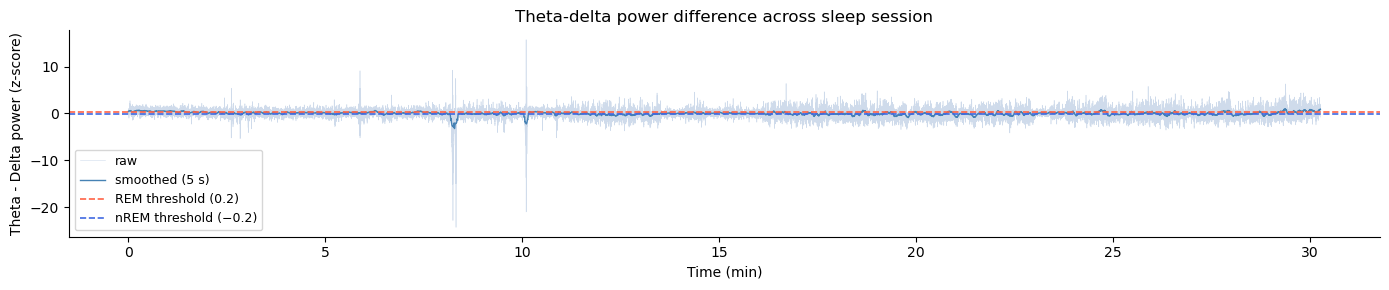

In [6]:
fig, ax = plt.subplots(figsize=(14, 3))
ax.plot(t / 60, power_diff, lw=0.4, color='lightsteelblue', alpha=0.6, label='raw')
ax.plot(t / 60, power_diff_smooth, lw=1.0, color='steelblue', label='smoothed (5 s)')
ax.axhline(0.2,  color='tomato',    lw=1.2, ls='--', label='REM threshold (0.2)')
ax.axhline(-0.2, color='royalblue', lw=1.2, ls='--', label='nREM threshold (−0.2)')
ax.set_xlabel('Time (min)')
ax.set_ylabel('Theta - Delta power (z-score)')
ax.set_title('Theta-delta power difference across sleep session')
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


In [7]:
threshold = 0.2

rem_mask  = power_diff_smooth >  threshold   # threshold on smoothed signal
nrem_mask = power_diff_smooth < -threshold

print(f'REM  : {rem_mask.mean()*100:.1f}% of recording')
print(f'nREM : {nrem_mask.mean()*100:.1f}% of recording')


REM  : 21.6% of recording
nREM : 20.3% of recording


In [8]:
def get_epochs(mask, min_dur_s=2.0):
    """Return list of (start_idx, end_idx) for contiguous True runs >= min_dur_s."""
    d = np.diff(mask.astype(int))
    starts = np.where(d ==  1)[0] + 1
    ends   = np.where(d == -1)[0] + 1
    if mask[0]:  starts = np.r_[0, starts]
    if mask[-1]: ends   = np.r_[ends, len(mask)]
    return [(s, e) for s, e in zip(starts, ends)
            if (e - s) / fs >= min_dur_s]

rem_epochs  = get_epochs(rem_mask)
nrem_epochs = get_epochs(nrem_mask)
print(f'{len(rem_epochs)} REM epochs,  {len(nrem_epochs)} nREM epochs')

43 REM epochs,  59 nREM epochs


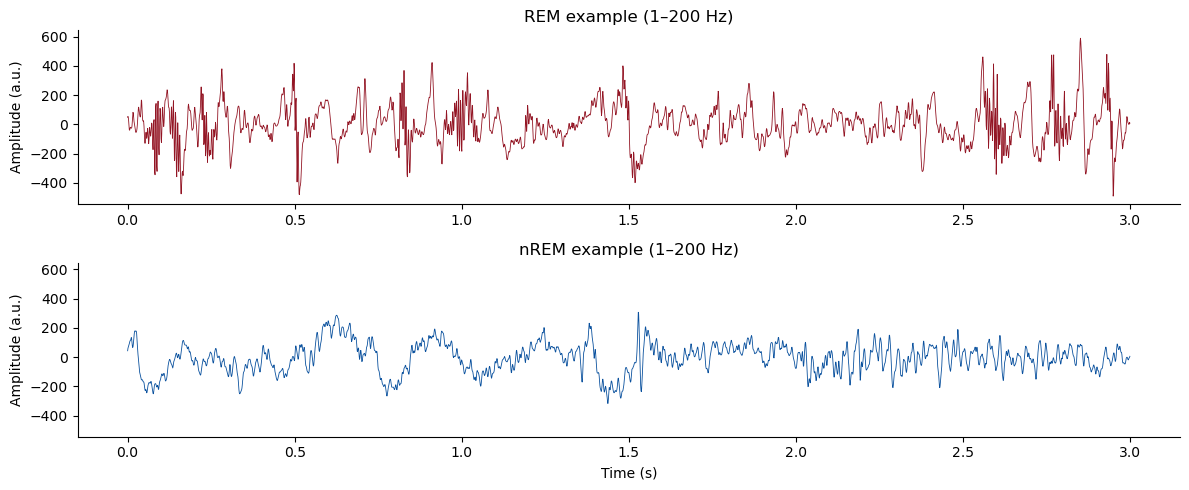

In [9]:
# wideband filter 1–200 Hz to reduce noise
lfp_wide = bandpass_filter(lfp, low_f=1, high_f=200, sampling_rate=fs, filter_order=4)

def pick_epoch(epochs, idx=None):
    """Pick a long, mid-session epoch for plotting."""
    if idx is None:
        idx = len(epochs) // 2
    return epochs[idx]

s_rem,  e_rem  = pick_epoch(rem_epochs)
s_nrem, e_nrem = pick_epoch(nrem_epochs)
plot_s = int(3 * fs)      # show 3 seconds

fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharey=True)
for ax, start, label, color in zip(
        axes,
        [s_rem,  s_nrem],
        ['REM',  'nREM'],
        ["#931524", "#0A519E"]):
    seg = lfp_wide[start : start + plot_s]
    t_ex = np.arange(len(seg)) / fs
    ax.plot(t_ex, seg, lw=0.6, color=color)
    ax.set_title(f'{label} example (1–200 Hz)')
    ax.set_ylabel('Amplitude (a.u.)')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
axes[-1].set_xlabel('Time (s)')
plt.tight_layout()
plt.show()

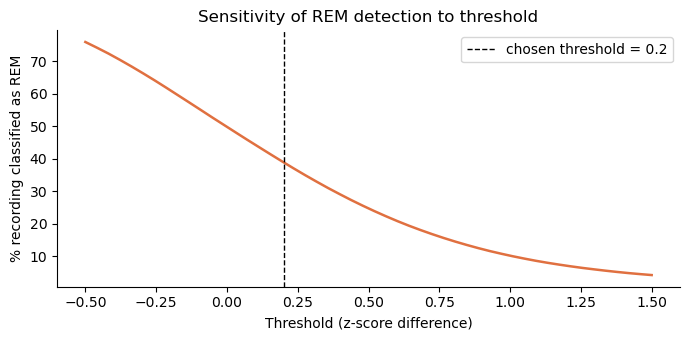

In [10]:
thresholds = np.linspace(-0.5, 1.5, 50)
rem_pct = [(power_diff > thr).mean() * 100 for thr in thresholds]

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(thresholds, rem_pct, color='#E07040', lw=1.8)
ax.axvline(threshold, color='k', ls='--', lw=1, label=f'chosen threshold = {threshold}')
ax.set_xlabel('Threshold (z-score difference)')
ax.set_ylabel('% recording classified as REM')
ax.set_title('Sensitivity of REM detection to threshold')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()